Name: Lama Alfreah.

# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [3]:
import pandas as pd
import sklearn

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [14]:
df= pd.read_csv("advertising.csv")
df = df.drop(columns=["Unnamed: 0"])

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Step 2.a Assign variables `X` to the features and `y` to the target

In [16]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

### Step 2.b print the type of each

In [17]:
display(X .dtypes)
display(y .dtype)

TV           float64
radio        float64
newspaper    float64
dtype: object

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Target is numerical → Regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [21]:
X.shape

(200, 3)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [22]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [23]:
ranges = X.max() - X.min()
print("Feature ranges:\n", ranges)


Feature ranges:
 TV           295.7
radio         49.6
newspaper    113.7
dtype: float64


### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

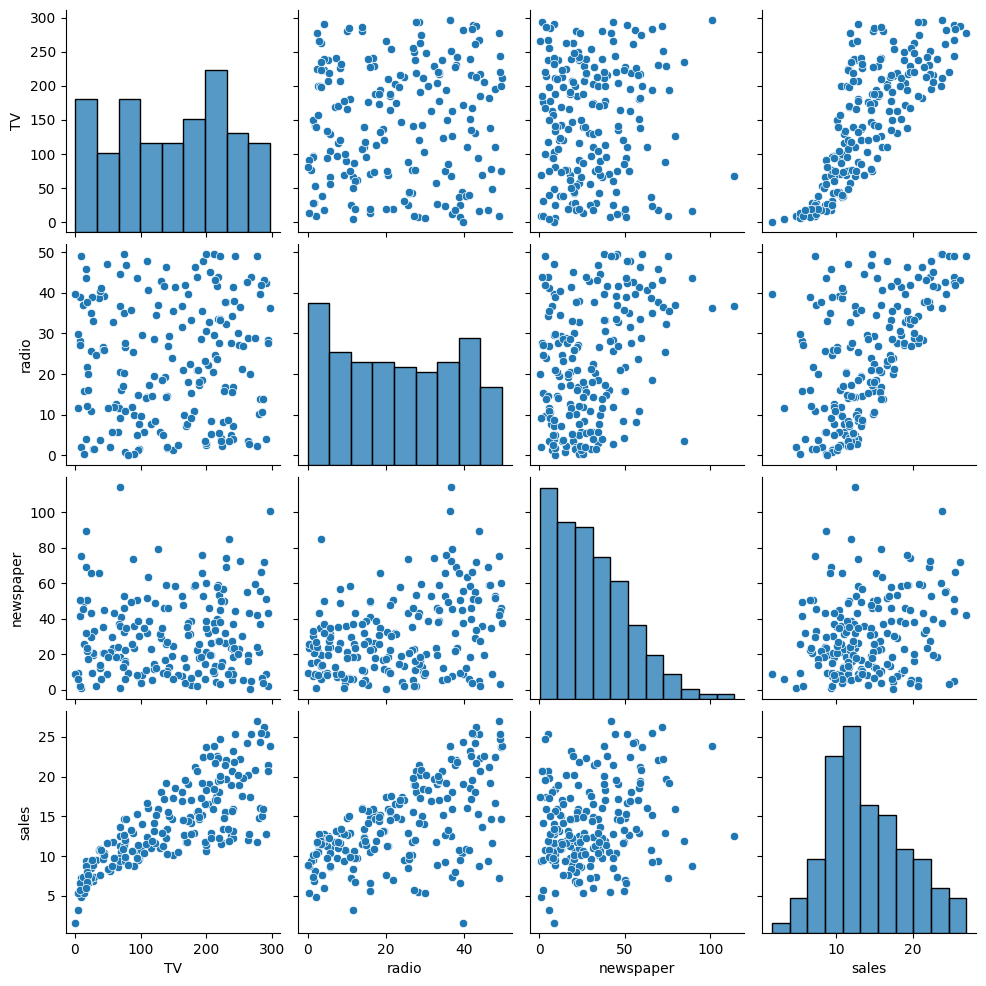

In [24]:
import seaborn as sns

sns.pairplot(df)

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

1. TV vs Sales > increasing
2. Radio vs Sales > increasing
3. Newspaper vs Sales > none


### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]
)

### Step 8. Split the dataset into train and test sets

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9.a Fit the pipeline on the training set

In [29]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [31]:
model = pipe.named_steps["model"]
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [3.76419618 2.79230665 0.05597551]
Intercept: 14.100000000000001


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [32]:
print("TV coefficient:", model.coef_[0])

TV coefficient: 3.764196175146996


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [36]:
print("Radio coef:", model.coef_[1])
print("Newspaper coef:", model.coef_[2])
change = (model.coef_[1] * 5) - (model.coef_[2] * 5)
print(change)

Radio coef: 2.7923066501984377
Newspaper coef: 0.05597551446265244
13.681655678678926


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [34]:
print("Estimated sales with no ads:", model.intercept_)

Estimated sales with no ads: 14.100000000000001


### Step 10. Evaluate the pipeline on the test set

In [35]:
score = pipe.score(X_test, y_test)

### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?